# Big Data, Machine Learning y la Hipótesis de Mercados Eficientes (EMH)
En esta actividad, exploraremos cómo los conceptos de predicción de precios utilizando modelos econométricos se relacionan con la Hipótesis de Mercados Eficientes (EMH). También aprenderemos a aplicar estos conceptos en un contexto práctico de inversión.

## Preparación de los Datos
Primero, obtendremos los datos históricos de un activo financiero (por ejemplo, BNB-USD o S&P 500) y prepararemos las series temporales necesarias para nuestro análisis.

In [9]:
# Importar bibliotecas necesarias
#!pip install yfinance pandas matplotlib scikit-learn statsmodels arch openpyxl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.ar_model import AutoReg
import yfinance as yf
from arch import arch_model

# Descargar datos históricos de BNB-USD usando yfinance
ticker = "BNB-USD"
data = yf.download(ticker, start="2021-01-01", end="2022-04-18")
bnb = data['Open']

# Mostrar las primeras y últimas filas de los datos
bnb.head(), bnb.tail()


Failed to get ticker 'BNB-USD' reason: Expecting value: line 1 column 1 (char 0)
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['BNB-USD']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')


(Series([], Name: Open, dtype: float64),
 Series([], Name: Open, dtype: float64))

In [10]:
# Crear variables rezagadas
bnb_lag1 = bnb.shift(1)
bnb_lag2 = bnb.shift(2)

# Combinar los datos en un DataFrame
data = pd.concat([bnb, bnb_lag1, bnb_lag2], axis=1)
data.columns = ['bnb', 'bnb_1', 'bnb_2']
data.dropna(inplace=True)

# Mostrar las primeras filas de los datos
data.head()



,bnb,bnb_1,bnb_2
Date,,,


In [11]:
# Dividir los datos en 80% entrenamiento y 20% prueba
train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]

# Separar variables dependientes e independientes
X_train, y_train = train[['bnb_1', 'bnb_2']], train['bnb']
X_test, y_test = test[['bnb_1', 'bnb_2']], test['bnb']


In [12]:
# Crear el modelo de regresión
model = LinearRegression()
model.fit(X_train, y_train)

# Mostrar coeficientes del modelo
print("Coeficientes del modelo:", model.coef_)
print("Intercepto del modelo:", model.intercept_)

# Realizar predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# Calcular el RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE de la predicción: {rmse}")


ValueError: Found array with 0 sample(s) (shape=(0, 2)) while a minimum of 1 is required by LinearRegression.

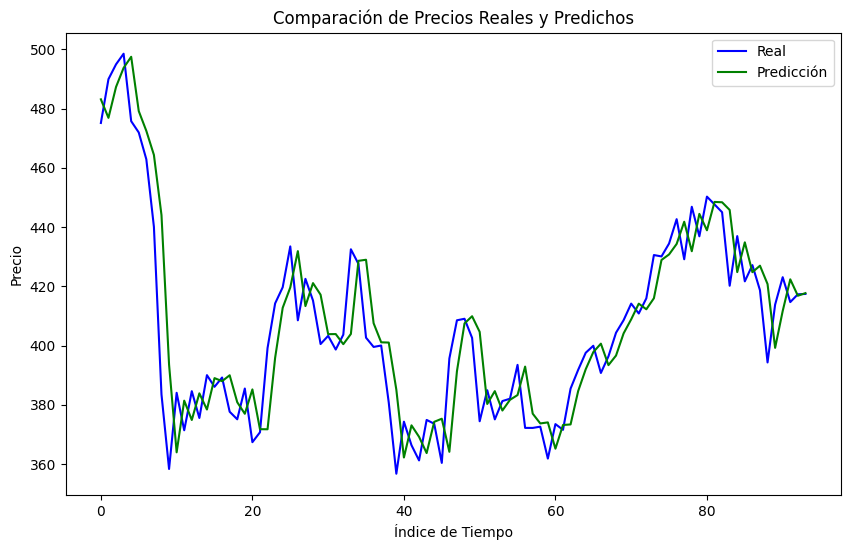

In [ ]:
# Graficar los valores reales y predichos
plt.figure(figsize=(10,6))
plt.plot(y_test.values, label='Real', color='blue')
plt.plot(y_pred, label='Predicción', color='green')
plt.title('Comparación de Precios Reales y Predichos')
plt.xlabel('Índice de Tiempo')
plt.ylabel('Precio')
plt.legend()
plt.show()
